In [1]:
from define_system import *
from steady_state_KF import *
from simulate import *
from dataloader import *
from ARmodel import *
from train_test import *

In [2]:
n=4
p=2
m=3
rho_target=1.0
sys_seed = 0

A, B, C = define_system(n, p, m, rho_target, seed=sys_seed)
W = 0.05 * np.eye(n)
V = 0.1 * np.eye(m)

Spectral radius of A:  1.0000000000000007
Observable? True (rank 4 of 4)
Controllable? True (rank 4 of 4)


In [3]:
# ---- run sweep ----
L_values = [3,5,7,10]
H=1
dist_type = 'gaussian'

T_list = [i for i in range(200, 20200, 200)]

dfs = {}

for L in L_values:
    print(f"Running for L={L}")
    df_L = run_sweep(
        A,
        B,
        C,
        W,
        V,
        T_list,
        repeats=5,
        L=L,
        H=H,
        testT=1000,
        epochs=150,
        batch_size=64,
        lr=0.05,
        step_size=2,
        gamma=0.9,
        lambda_reg=1e-3,
        test_seed=20,
        base_train_seed=10,
        base_torch_seed=1000,
        test_umode='ramp_bias',
        dist_type=dist_type
    )
    dfs[L] = df_L

Running for L=3
Running for L=5
Running for L=7
Running for L=10


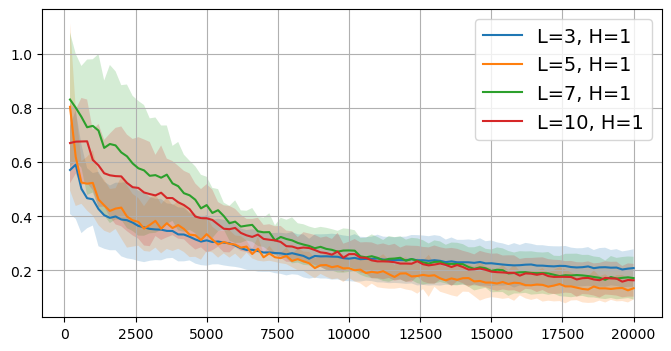

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

for L in L_values:
    df_L = dfs[L]
    x = df_L["T"].to_numpy()
    y = df_L["mean_l2_mean"].to_numpy()
    s = df_L["mean_l2_std"].to_numpy()

    plt.plot(x, y, label=f"L={L}, H={H}")
    plt.fill_between(x, y - s, y + s, alpha=0.2)

# plt.xlabel("Length of Train Trajectory (T)")
# plt.ylabel(r"Error: mean $\|x_{\mathrm{KF}} - x_{\mathrm{learned}}\|_2$ (test)")
# plt.title(f"Sample complexity with noise distribution: {dist_type}")
plt.grid(True)
plt.legend(fontsize=14)
plt.savefig("figs/sample_complexity_h1.png")
plt.show()

In [7]:
import pandas as pd

In [11]:
dfs[3].to_csv("L3H1.csv", index=False)

In [12]:
dfs[5].to_csv("L5H1.csv", index=False)
dfs[7].to_csv("L7H1.csv", index=False)
dfs[10].to_csv("L10H1.csv", index=False)

In [13]:
df51 = pd.read_csv("L5H1.csv")

In [15]:
dfs[5]

,T,mean_l2_mean,mean_l2_std
0,200,0.805067,0.309064
1,400,0.619743,0.181444
2,600,0.525014,0.078866
3,800,0.520696,0.099583
4,1000,0.523774,0.121481
...,...,...,...
95,19200,0.131254,0.040285
96,19400,0.133831,0.048331
97,19600,0.134900,0.048417
98,19800,0.126169,0.044730


In [14]:
df51

,T,mean_l2_mean,mean_l2_std
0,200,0.805067,0.309064
1,400,0.619743,0.181444
2,600,0.525014,0.078866
3,800,0.520696,0.099583
4,1000,0.523774,0.121481
...,...,...,...
95,19200,0.131254,0.040285
96,19400,0.133831,0.048331
97,19600,0.134900,0.048417
98,19800,0.126169,0.044730
